# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [47]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [49]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [50]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [51]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [52]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [53]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [54]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [55]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [56]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [57]:
# cantidad de nulos para usage
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Al revisar el bloque, mi diagnostico es investigar a fondo el DataFrame usage en las columnas duration y length que son las que presentan la mayor cantidad de valores nulos

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  En el DataFrame users, solo en la columna city hay valores nulos, estos son menor al 5%. En el DataFrame usage las columnas date, duration y length son las que tiene valores faltantes siendo la columna duration con el mayor numero de valores faltantes
- Indica qué harías: ¿imputar, eliminar, ignorar? Para users, ignorar ya que los valores faltanes son minimos. En cambio, en usage investigaria con mas detalle para decidir si imputar, eliminar o dejarlos como nulos

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [58]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Vemos que esta capturada de manera correcta ya que no hay valores nulos ni extremos
- La columna `age` Podemos ver extremos en el minimo, lo cual indica que tien valores nulos o mal capturados

In [59]:
# explorar columnas numéricas de usage
usage[['id','user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id Ambas columnas muestran datos parecidos y sin valores nulos
- Las columnas se encuentran capturadas de manera correcta para su posterior analisis

In [60]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- Conteo para {col} ---")
    print(users[col].value_counts())
    print("\n")

--- Conteo para city ---
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Conteo para plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` vemos que la ciudad de Bogota es la mas se repite, indica que es donde hay mas clientes asi como tambien 96 valores nulos.
- La columna `plan` nos indica que la mayoria de clientes tienen un plan basico

In [61]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` nos dice que los clientes usan mas un texto que una llamada


---
✍️ **Comentario**: Despues de ver los resultados, el diagnostico es que hay sentinels en dos columnas, age del DataFrame users y city del DataFrame usage. Recomiendo usar la mediana para la columna age para modificar los sentinels y para city recomiendo dejarlos como estan

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? En la columna age y city es donde se encontraron valores invalidos
- ¿Qué acción tomarías?  Para la columna age, sustituirlos por la mediana y para la columna city sustituir esos valores como NA

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [62]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [63]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [64]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].value_counts()

2026-05-10 00:00:00.000000000    40
2023-12-20 18:33:45.506376600     1
2022-11-21 17:58:06.571642912     1
2024-06-20 09:50:54.463615904     1
2022-05-22 00:23:45.956489122     1
                                 ..
2022-07-29 04:44:06.661665416     1
2022-02-22 00:36:43.750937734     1
2022-10-31 09:22:49.242310580     1
2022-09-24 16:46:48.702175544     1
2022-03-28 12:38:20.975243811     1
Name: reg_date, Length: 3961, dtype: int64

En `reg_date`, convertida a tipo fecha vemos que hay algunos registros de fechas imposibles aunque son los minimos, recomiendo marcarlos como NaT para que al analisis sea claro

In [65]:
# Revisar los años presentes en `date` de usage
usage['date'].value_counts()

2024-06-16 13:26:59.770494262    1
2024-06-21 22:28:11.862296556    1
2024-06-06 11:09:26.204155102    1
2024-04-14 16:05:21.848046200    1
2024-04-01 14:39:43.079576989    1
                                ..
2024-04-13 22:49:17.653941348    1
2024-03-06 03:52:44.749118728    1
2024-03-21 23:20:13.140328508    1
2024-01-07 00:52:33.678841971    1
2024-04-08 01:44:47.917197929    1
Name: date, Length: 39950, dtype: int64

En `date`, En esta otra columna, en su mayoria las operaciones son del año 2024 hacia atras 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso: Despues de revisar los años en ambas columnas las operaciones mostradas son del año 2024 hacia atras. En ningun caso se muestran de años posteriores, asi que recomiendo dejarlas como estan. Son excelentes para analisis.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) No, no me aparecen años imposibles. Todos los años son del 2024 hacia atras.
- ¿Qué harías con ellas? Las dejaria tal como aparacen

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [66]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999,pd.NA)
users['age'] = age_mediana.median()

# Verificar cambios
users['age'].describe()

count    4000.0
mean       48.0
std         0.0
min        48.0
25%        48.0
50%        48.0
75%        48.0
max        48.0
Name: age, dtype: float64

In [67]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [68]:
# Marcar fechas futuras como NA para reg_date
hoy = pd.Timestamp('today')
users.loc[users['reg_date'] > hoy, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].value_counts()

2026-05-10 00:00:00.000000000    40
2023-12-20 18:33:45.506376600     1
2022-11-21 17:58:06.571642912     1
2024-06-20 09:50:54.463615904     1
2022-05-22 00:23:45.956489122     1
                                 ..
2022-07-29 04:44:06.661665416     1
2022-02-22 00:36:43.750937734     1
2022-10-31 09:22:49.242310580     1
2022-09-24 16:46:48.702175544     1
2022-03-28 12:38:20.975243811     1
Name: reg_date, Length: 3961, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [69]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [70]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Como diagnostico los nulos no son aleatorios, dependen de type. Un mensaje no tiene duración y una llamada no tiene longitud de texto asi que son MAR. En base a los resultados obtenidos, mi decision es mantener los nulos, no imputarlos. No son datos perdidos sino ausencias estructurales; rellenarlos con 0 o con la media crearía llamadas de duración cero y mensajes inexistentes, distorsionando todas las métricas de uso.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [71]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) 
usage["is_call"] = (usage["type"] == "call").astype(int) 
usage["call_minutes"] = np.where (usage['type']== "call", usage['duration'], 0)

# Agrupar información por usuario
usage_agg = usage.groupby(['user_id']).agg({'is_text':'sum','is_call':'sum','call_minutes':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [72]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','call_minutes':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [73]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users,on='user_id',how='inner')
user_profile = user_profile.drop('churn_date', axis=1)
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan
0,10000,7,3,23.70,Carlos,Garcia,48.0,Medellín,2022-01-01 00:00:00.000000000,Basico
1,10001,5,10,33.18,Mateo,Torres,48.0,<NA>,2022-01-01 06:34:17.914478619,Basico
2,10002,5,2,10.74,Sofia,Ramirez,48.0,CDMX,2022-01-01 13:08:35.828957239,Basico
3,10003,11,3,8.99,Mateo,Ramirez,48.0,Bogotá,2022-01-01 19:42:53.743435858,Premium
4,10004,4,3,8.01,Mateo,Torres,48.0,GDL,2022-01-02 02:17:11.657914478,Basico


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [74]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.0
mean,11999.729432,5.524381,4.478120,22.836934,48.0
std,1154.898108,2.358416,2.144238,16.590213,0.0
min,10000.000000,0.000000,0.000000,0.000000,48.0
25%,10999.500000,4.000000,3.000000,11.095000,48.0
50%,12000.000000,5.000000,4.000000,19.740000,48.0
75%,12999.500000,7.000000,6.000000,31.185000,48.0
max,13999.000000,17.000000,15.000000,155.690000,48.0


In [75]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

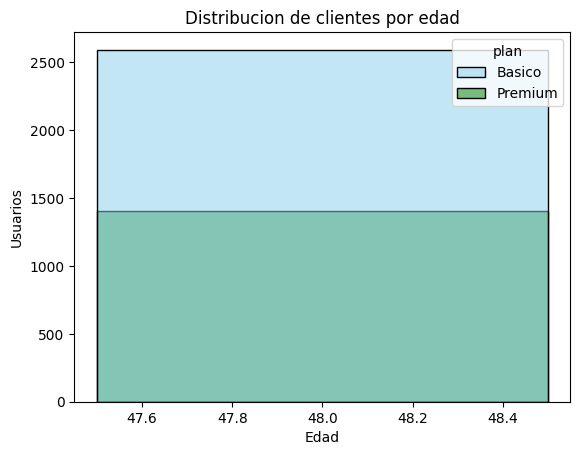

In [76]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribucion de clientes por edad')
plt.xlabel('Edad')
plt.ylabel('Usuarios')
plt.show()

💡Insights: 
- Distribución que se ve en el hisplot, hay mas usuarios con plan premium que basico. Y aqui se puede ver una distribucion simetrica.

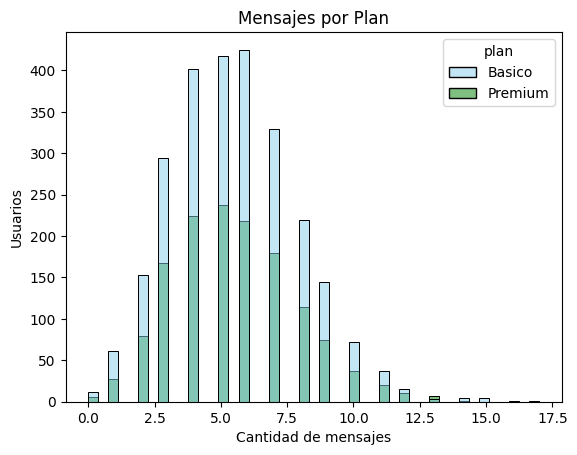

In [77]:
# Histograma para visualizar la cant_mensajes

sns.histplot(user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])

plt.title('Mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Usuarios')
plt.show()



💡Insights: 
De acuerdo al histogrma, de 410 usuarios, 210 son de plan basico y envian alrededor de 6 mensajes los otros 200 usuarios son de plan premium. Se nota una distribucion sesgada a la derecha.

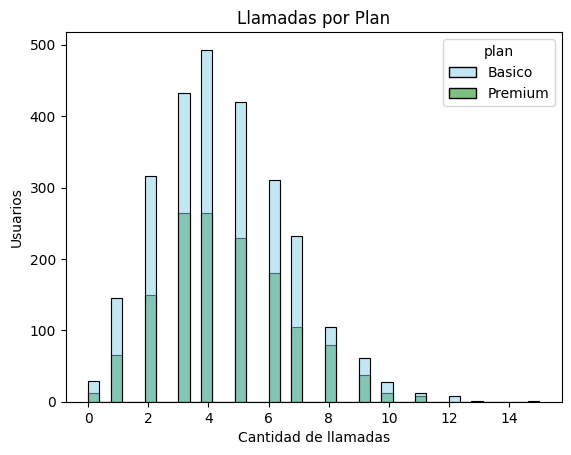

In [78]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Usuarios')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha, aproximadamente 300 usuarios de plan premium realizan 3-4 llamadas a diferencia de plan basico en el cual aproximadamente 200 usuarios hacen 3 llamadas pero tiene un aumento de usuarios que realizan 4 llamadas.

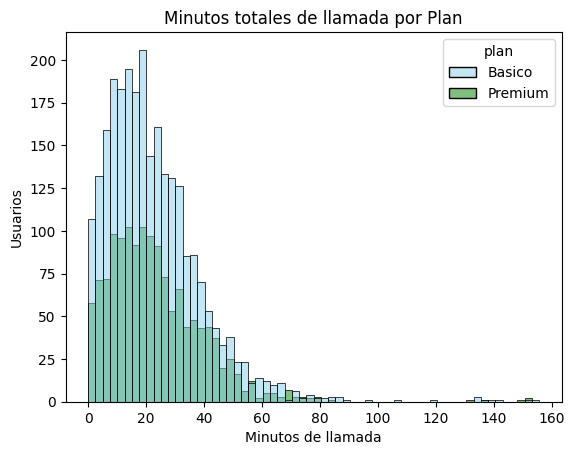

In [79]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])

plt.title('Minutos totales de llamada por Plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Usuarios')
plt.show()


💡Insights: 
De acuerdo al histograma, se nota una distribucion sesgada a la derecha. Asi mismo, se ve que aproximadamente 100 usuarios tanto en plan premium como basico realizan llamadas entre 20 y 25 minutos. El sesgo empieza a notarse conforme nos acercamos a los 40 minutos de llamadas siendo usuarios siendo mayor en el plan basico

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

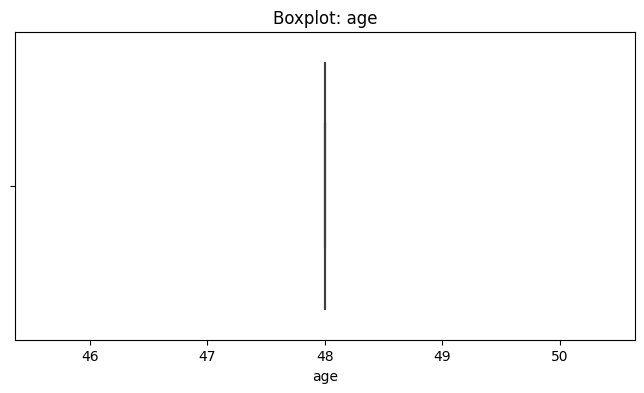

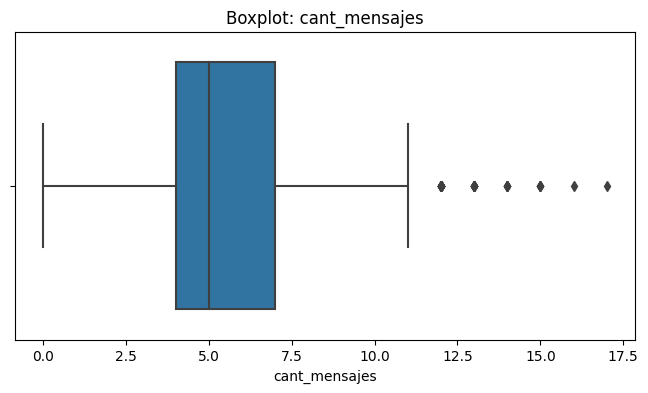

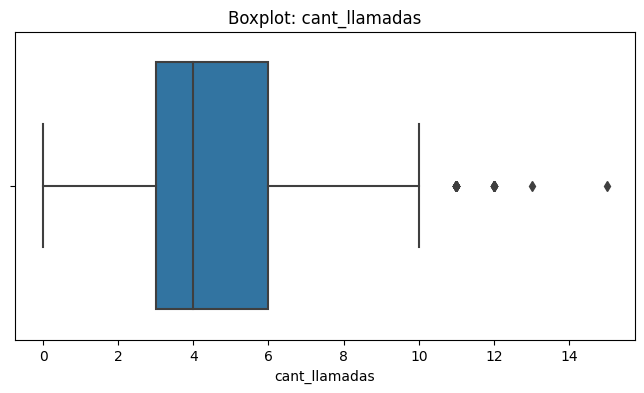

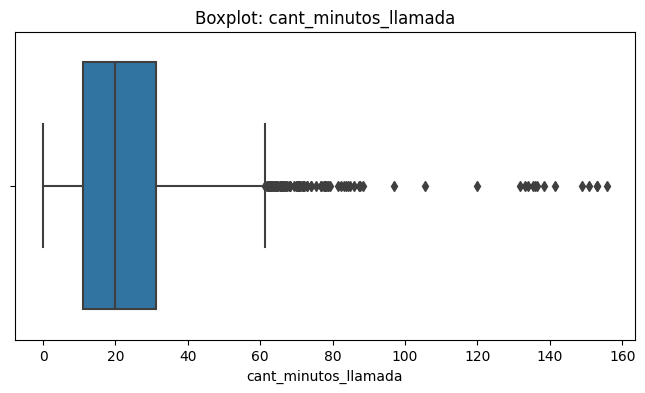

In [80]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta un sesgo a la derecha en donde estan los outliers los cuales son minimos y no representan conflicto para el analisis
- cant_llamadas: De la misma manera, hay un sesgo a la derecha donde los outliers son minimos y no presentarian conflicto para el analisis
- cant_minutos_llamada: Del mismo modo presenta un sesgo a la derecha, en este caso los outliers se presentan de manera dispersa lo cual podrian indicar error en la medicion de los minutos de llamada, por ejemplo. 

In [118]:
# Calcular límites con el método IQR
columnas_limites = []



In [119]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

ValueError: Cannot describe a DataFrame without columns

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? R= Mantendria los outliers porque no alteran el analisis
- cant_llamadas: mantener o no outliers, porqué? R= Del mismo modo, mantendria los outliers porque no alteran el analisis
- cant_minutos_llamada: mantener o no outliers, porqué? R= En este caso mantendria los outliers para su analisis al detalle y posteriormente decidir si se quedan o se eliminan. Esto porque son muchos y se encuentran de manera dispersa, si se eliminan de tajo se podria perder informacion y afectar el analisis principal asi como la decision final

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [81]:
# Crear columna grupo_uso

condiciones = [(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)]
opciones = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')


In [82]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,48.0,Medellín,2022-01-01 00:00:00.000000000,Basico,Uso medio
1,10001,5,10,33.18,Mateo,Torres,48.0,<NA>,2022-01-01 06:34:17.914478619,Basico,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,48.0,CDMX,2022-01-01 13:08:35.828957239,Basico,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,48.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,Alto uso
4,10004,4,3,8.01,Mateo,Torres,48.0,GDL,2022-01-02 02:17:11.657914478,Basico,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [83]:
# Crear columna grupo_edad
condiciones = [(user_profile['age'] < 30), (user_profile['age'] < 60)]
opciones = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(condiciones, opciones, default='Adulto Mayor')

In [84]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,48.0,Medellín,2022-01-01 00:00:00.000000000,Basico,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,48.0,<NA>,2022-01-01 06:34:17.914478619,Basico,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,48.0,CDMX,2022-01-01 13:08:35.828957239,Basico,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,48.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,Alto uso,Adulto
4,10004,4,3,8.01,Mateo,Torres,48.0,GDL,2022-01-02 02:17:11.657914478,Basico,Bajo uso,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

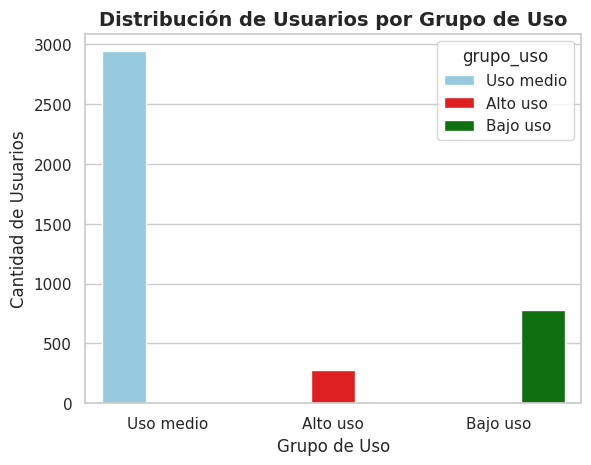

In [95]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x="grupo_uso", hue="grupo_uso",  palette=("skyblue", "red", "green"))
plt.title( "Distribución de Usuarios por Grupo de Uso", fontsize=14, fontweight="bold")
plt.xlabel("Grupo de Uso", fontsize=12)
plt.ylabel("Cantidad de Usuarios", fontsize=12)
plt.show()


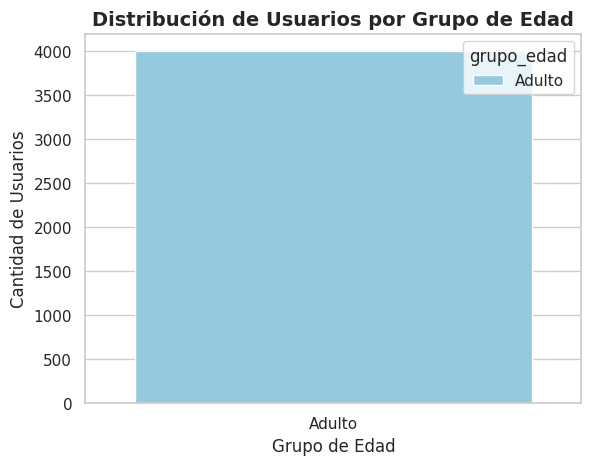

In [96]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", hue="grupo_edad",  palette=("skyblue", "red", "green"))
plt.title( "Distribución de Usuarios por Grupo de Edad", fontsize=14, fontweight="bold")
plt.xlabel("Grupo de Edad", fontsize=12)
plt.ylabel("Cantidad de Usuarios", fontsize=12)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos? R= Los problems que tenian eran de datos faltantes en la columna city del df user_id y en el segundo df usage en las columnas date, duration y length. 

- ¿Qué porcentaje, o cantidad de filas, de esa columna representaban? R= Del df user_id, columna city no representaba algo significativo aqui se pudo solucionar con una sustitucion de valores. En cambio en las otras tres columnas del segundo df usage, se realizaron diferentes metodos. En date las fechas faltantes se marcaron como NaT ya que los faltantes eran minimos. En duration, como el nombre lo indica, los faltantes eran las filas que no eran llamadas y en length fueron marcados como NA


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso? R= la mayoria de usuarios son de uso medio en la edad adulta, esto es <60 años
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  El segmento de uso medio y la edad adulto <60, son los usuarios mas valiosos. Porque en esos segmentos se presentan la mayor cantidad de usuarios.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio? R= En su mayoria los encontre en columnas con datos de fecha de registro ya que esos datos solo estan hasta 2024 asi mismo en la columna de duration pero el detalle en esta es que el faltante es en filas que indican que fueron mensajes en lugar de llamadas y fueron minimos en comparacion con la columna reg_date y date.
Esto nos indica que hay una fuga de datos al momento de capturar fechas ya sea de registro o cuando se contrata algun plan (basico o premium).

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
De acuerdo a lo detectado, recomendaria mejorar la oferta actual mas enfocado a los jovenes ya que es un segmento que aumenta y que siempre le gusta estar a la vanguardia y esto haria que ese segmento aumentara el uso, asi mismo crear un plan mas adecuado para un adulto mayor, enfocado a sus necesidades.
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Outliers en datos de fecha
- Outliers extremos en datos de minutos de llamada


🔍 **Segmentos por Edad**
- La mayoria de usuarios se concentran en edad Adulta, mayores de 30 y menores de 60



📊 **Segmentos por Nivel de Uso**
- La mayoria de usuarios son de nivel uso medio
- En segundo lugar de bajo uso y en menor medida un alto uso


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Identificar el problema al momento de capturar las datos de fecha
- Armar un nuevo plan enfocado a los jovenes (menores de 30 años)
- Ampliar la oferta actual para los adultos ya que la mayoria de usuarios se encuentran dentro de este segmento

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`